### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [2]:
data = pd.read_csv('data/coupons.csv')
len(data)

12684

In [3]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [4]:
data.isnull().sum()

destination                 0
passanger                   0
weather                     0
temperature                 0
time                        0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64

3. Decide what to do about your missing data -- drop, replace, other...

In [5]:
# since total number of rows is 12684 and there are 12576 rows are missing "car" column.  Drop the "car" column
data_new=data.drop(columns='car')
# for the other columns, there are only a small amount of missing data.  so just drop these rows with missing data
data_new = data_new.dropna()
data_new.isnull().sum()
len(data_new)

12079

4. What proportion of the total observations chose to accept the coupon?



In [6]:
round(len(data_new[data_new['Y']==1])/len(data_new)*100,2)

56.93

5. Use a bar plot to visualize the `coupon` column.

Text(0.5, 1.0, 'Count of Each Coupon Type')

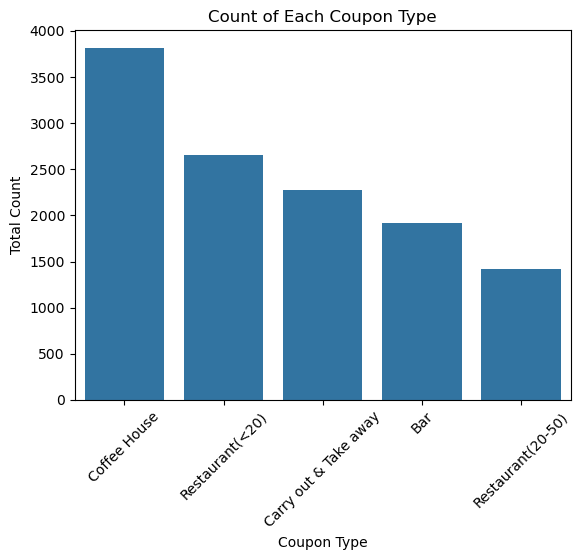

In [7]:
#data_new.plot(kind='bar', x='coupon',y='Y',figsize=(8,5))
f1=sns.barplot(x=data_new['coupon'].value_counts().index,y=data_new['coupon'].value_counts()) 
f1.tick_params(axis='x', rotation=45)
f1.set(xlabel='Coupon Type', ylabel='Total Count')
f1.set_title('Count of Each Coupon Type')

6. Use a histogram to visualize the temperature column.

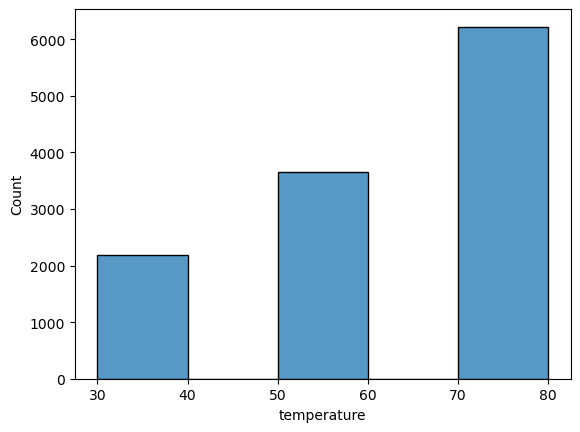

In [8]:
f2=sns.histplot(data=data_new, x='temperature',binwidth=10)

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [9]:
data_new['coupon'].unique()

array(['Restaurant(<20)', 'Coffee House', 'Bar', 'Carry out & Take away',
       'Restaurant(20-50)'], dtype=object)

In [10]:
df_bar=data_new.query("coupon=='Bar'")
df_bar.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1913 entries, 24 to 12682
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           1913 non-null   object
 1   passanger             1913 non-null   object
 2   weather               1913 non-null   object
 3   temperature           1913 non-null   int64 
 4   time                  1913 non-null   object
 5   coupon                1913 non-null   object
 6   expiration            1913 non-null   object
 7   gender                1913 non-null   object
 8   age                   1913 non-null   object
 9   maritalStatus         1913 non-null   object
 10  has_children          1913 non-null   int64 
 11  education             1913 non-null   object
 12  occupation            1913 non-null   object
 13  income                1913 non-null   object
 14  Bar                   1913 non-null   object
 15  CoffeeHouse           1913 non-null   obj

2. What proportion of bar coupons were accepted?


In [11]:
bar_coupon_accepted=df_bar['Y'].value_counts()[1]
print("counts of accepted bar coupon: ", bar_coupon_accepted)
bar_coupon_total=df_bar['Y'].count()
print("counts of total bar coupon: ", bar_coupon_total)
Bar_coupon_acceptance_rate=round(bar_coupon_accepted/bar_coupon_total*100,2)
print('Acceptance rate: ', Bar_coupon_acceptance_rate, '%')

counts of accepted bar coupon:  788
counts of total bar coupon:  1913
Acceptance rate:  41.19 %


3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [12]:
df_bar['Bar'].unique()

array(['never', 'less1', '1~3', 'gt8', '4~8'], dtype=object)

In [13]:
high_frequency = ['gt8', '4~8']
df_bar['frequentBarVisitor']= df_bar['Bar'].isin(high_frequency)
df_bar['frequentBarVisitor'].value_counts()

C:\Users\JPM\AppData\Local\Temp\ipykernel_11512\3154346417.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_bar['frequentBarVisitor']= df_bar['Bar'].isin(high_frequency)


frequentBarVisitor
False    1720
True      193
Name: count, dtype: int64

In [14]:
acceptance_rate_less_frequent = round(len(df_bar[(df_bar['Y']==1)&(df_bar['frequentBarVisitor']==False)])/len(df_bar[df_bar['frequentBarVisitor']==False])*100,2)
# len(df_bar[(df_bar['Y']==1)&(df_bar['frequentBarVisitor']==False)])

# acceptance_rate_less_frequent
acceptance_rate_more_frequent = round(len(df_bar[(df_bar['Y']==1)&(df_bar['frequentBarVisitor']==True)])/len(df_bar[df_bar['frequentBarVisitor']==True])*100,2)
# len(df_bar[(df_bar['Y']==1)&(df_bar['frequentBarVisitor']==False)])

print('Acceptance rate of people who visits bar less than or equal to 3 times per month: ', acceptance_rate_less_frequent, '%')
print('Acceptance rate of people who visits bar more than 3 times per month: ', acceptance_rate_more_frequent, '%')

Acceptance rate of people who visits bar less than or equal to 3 times per month:  37.27 %
Acceptance rate of people who visits bar more than 3 times per month:  76.17 %


4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [15]:
more_than_once =['1~3', 'gt8', '4~8']
older_than_25=['46', '26', '31', '41', '50plus', '36']
df_bar['moreThanOnce&over25']=(df_bar['Bar'].isin(more_than_once))&(df_bar['age'].isin(older_than_25))
df_bar['moreThanOnce&over25'].value_counts()

C:\Users\JPM\AppData\Local\Temp\ipykernel_11512\2973705493.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_bar['moreThanOnce&over25']=(df_bar['Bar'].isin(more_than_once))&(df_bar['age'].isin(older_than_25))


moreThanOnce&over25
False    1510
True      403
Name: count, dtype: int64

In [16]:
# acceptance rate of moreThanOnce&over25
temp1=len(df_bar[(df_bar['Y']==1)&(df_bar['moreThanOnce&over25']==True)])
temp2=len(df_bar[(df_bar['moreThanOnce&over25']==True)])
acceptance_rate_moreThanOnce_over25 = round(temp1/temp2*100,2)
# print(len(df_bar[df_bar['moreThanOnce&over25']==True]))
# acceptance_rate_of others
acceptance_rate_others = round(len(df_bar[(df_bar['Y']==1)&(df_bar['moreThanOnce&over25']==False)])/len(df_bar[df_bar['moreThanOnce&over25']==False])*100,2)


print('Acceptance rate of people who visits bar more than once a month and are over the age of 25: ', acceptance_rate_moreThanOnce_over25, '%')
print('Acceptance rate of others: ', acceptance_rate_others, '%')

Acceptance rate of people who visits bar more than once a month and are over the age of 25:  68.98 %
Acceptance rate of others:  33.77 %


5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [17]:
# df_bar['passanger'].unique()
df_bar['occupation'].unique()

array(['Architecture & Engineering', 'Student',
       'Education&Training&Library', 'Unemployed', 'Healthcare Support',
       'Healthcare Practitioners & Technical', 'Sales & Related',
       'Management', 'Arts Design Entertainment Sports & Media',
       'Computer & Mathematical', 'Life Physical Social Science',
       'Personal Care & Service', 'Office & Administrative Support',
       'Construction & Extraction', 'Legal', 'Retired',
       'Community & Social Services', 'Installation Maintenance & Repair',
       'Transportation & Material Moving', 'Business & Financial',
       'Protective Service', 'Food Preparation & Serving Related',
       'Production Occupations',
       'Building & Grounds Cleaning & Maintenance',
       'Farming Fishing & Forestry'], dtype=object)

In [18]:
adult_passengers=['Friend(s)', 'Partner']
df_bar['moreThanOnce_adultPassengers_notFFF']=(df_bar['Bar'].isin(more_than_once))&(df_bar['passanger'].isin(adult_passengers))&(df_bar['occupation']!='Farming Fishing & Forestry')
df_bar['moreThanOnce_adultPassengers_notFFF'].value_counts()

C:\Users\JPM\AppData\Local\Temp\ipykernel_11512\99653867.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_bar['moreThanOnce_adultPassengers_notFFF']=(df_bar['Bar'].isin(more_than_once))&(df_bar['passanger'].isin(adult_passengers))&(df_bar['occupation']!='Farming Fishing & Forestry')


moreThanOnce_adultPassengers_notFFF
False    1724
True      189
Name: count, dtype: int64

In [19]:
temp1=len(df_bar[(df_bar['Y']==1)&(df_bar['moreThanOnce_adultPassengers_notFFF']==True)])
temp2=len(df_bar[(df_bar['moreThanOnce_adultPassengers_notFFF']==True)])
acceptance_rate_moreThanOnce_adultPassengers_notFFF = round(temp1/temp2*100,2)

# acceptance_rate_of others
temp3=len(df_bar[(df_bar['Y']==1)&(df_bar['moreThanOnce_adultPassengers_notFFF']==False)])
temp4=len(df_bar[df_bar['moreThanOnce_adultPassengers_notFFF']==False])
acceptance_rate_others = round(temp3/temp4*100,2)


print('Acceptance rate of people who visits bar more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry: ', acceptance_rate_moreThanOnce_adultPassengers_notFFF, '%')
print('Acceptance rate of others: ', acceptance_rate_others, '%')

Acceptance rate of people who visits bar more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry:  71.43 %
Acceptance rate of others:  37.88 %


6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [23]:
df_bar['maritalStatus'].value_counts()

maritalStatus
Married partner      833
Single               638
Unmarried partner    352
Divorced              73
Widowed               17
Name: count, dtype: int64

In [24]:
not_widowed=['Married partner','Single','Unmarried partner','Divorced']
df_bar['moreThanOnce_adultPassengers_notWidowed']=(df_bar['Bar'].isin(more_than_once))&(df_bar['passanger'].isin(adult_passengers))&(df_bar['maritalStatus'].isin(not_widowed))
temp5=len(df_bar[(df_bar['Y']==1)&(df_bar['moreThanOnce_adultPassengers_notWidowed']==True)])
temp6=len(df_bar[(df_bar['moreThanOnce_adultPassengers_notWidowed']==True)])
# acceptance_rate_moreThanOnce_adultPassengers_notWidowed=round(len(df_bar[(df_bar['Y']==1)&(df_bar['moreThanOnce_adultPassengers_notWidowed']==True)])/len(df_bar[(df_bar['moreThanOnce_adultPassengers_notWidowed']==True)])*100, 2)
acceptance_rate_moreThanOnce_adultPassengers_notWidowed=round(temp5/temp6*100,2)
print('Acceptance rate of people who visits bar more than once a month and had passengers that were not a kid and not widowed: ', acceptance_rate_moreThanOnce_adultPassengers_notWidowed, '%')


Acceptance rate of people who visits bar more than once a month and had passengers that were not a kid and not widowed:  71.43 %


C:\Users\JPM\AppData\Local\Temp\ipykernel_11512\63796549.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_bar['moreThanOnce_adultPassengers_notWidowed']=(df_bar['Bar'].isin(more_than_once))&(df_bar['passanger'].isin(adult_passengers))&(df_bar['maritalStatus'].isin(not_widowed))


In [28]:
df_bar['age'].unique()
less_than_30=['21', '26', 'below21']
df_bar['moreThanOnce_lessThan30']=(df_bar['Bar'].isin(more_than_once))&(df_bar['age'].isin(less_than_30))
temp7=len(df_bar[(df_bar['Y']==1)&(df_bar['moreThanOnce_lessThan30']==True)])
temp8=len(df_bar[(df_bar['moreThanOnce_lessThan30']==True)])
acceptance_rate_moreThanOnce_lessThan30=round(temp7/temp8*100,2)
print('Acceptance rate of people who visits bar more than once a month and less Than 30: ', acceptance_rate_moreThanOnce_lessThan30, '%')


Acceptance rate of people who visits bar more than once a month and less Than 30:  71.95 %


C:\Users\JPM\AppData\Local\Temp\ipykernel_11512\2414091439.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_bar['moreThanOnce_lessThan30']=(df_bar['Bar'].isin(more_than_once))&(df_bar['age'].isin(less_than_30))


In [33]:
df_bar['RestaurantLessThan20'].unique()
cheapRestaurant_moreThan4 = ['4~8', 'gt8']
df_bar['income'].unique()
income_lessThank50K = ['$12500 - $24999','$37500 - $49999', '$25000 - $37499','Less than $12500']
df_bar['cheapRestaurantMoreThan4_incomeLessThan50K']=(df_bar['RestaurantLessThan20'].isin(cheapRestaurant_moreThan4))&(df_bar['income'].isin(income_lessThank50K))
temp9=len(df_bar[(df_bar['Y']==1)&(df_bar['cheapRestaurantMoreThan4_incomeLessThan50K']==True)])
temp10=len(df_bar[(df_bar['cheapRestaurantMoreThan4_incomeLessThan50K']==True)])
acceptance_rate_cheapRestaurantMoreThan4_incomeLessThan50K=round(temp9/temp10*100,2)
print('Acceptance rate of people who go to cheap restaurants more than 4 times a month and income is less than 50K: ', acceptance_rate_cheapRestaurantMoreThan4_incomeLessThan50K, '%')

Acceptance rate of people who go to cheap restaurants more than 4 times a month and income is less than 50K:  45.65 %


C:\Users\JPM\AppData\Local\Temp\ipykernel_11512\3482862164.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_bar['cheapRestaurantMoreThan4_incomeLessThan50K']=(df_bar['RestaurantLessThan20'].isin(cheapRestaurant_moreThan4))&(df_bar['income'].isin(income_lessThank50K))


7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

In [35]:
# The highest bar coupon acceptance rate happens to people who visits bar more than 3 times per month:  76.17 %
# The other factors such as passengers, occupation, age, widowed or not, do not have a significant impact on the acceptance rate.
# Income less than 50K also significantly reduced the acceptance rate.

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  